In [1]:

# Initial exploration - load necessary libraries and understand the analysis requirement
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from scipy.optimize import curve_fit
import json
import os

# Check what files exist in the working directory
print("Files in current directory:")
for root, dirs, files in os.walk('.'):
 for file in files:
 if file.endswith(('.csv', '.parquet', '.json', '.npy')):
 print(f" {os.path.join(root, file)}")


Files in current directory:
 ./.config/matplotlib/fontlist-v390.json


In [2]:

# The dataset is not present. According to the research objective, I need to:
# 1. Generate partial sum values |D_{L_DH}(t; N)| for N=10^6 over t ∈ [1000, 10000]
# 2. Use the corrected squarefree-enforced implementation
# 
# First, let me implement the Davenport-Heilbronn function with corrected coefficients

def mobius(n):
 """
 Compute the Möbius function μ(n).
 Returns:
 - 1 if n is squarefree with an even number of prime factors
 - -1 if n is squarefree with an odd number of prime factors
 - 0 if n is not squarefree (has a squared prime factor)
 """
 if n == 1:
 return 1
 
 # Factor n
 temp_n = n
 num_prime_factors = 0
 
 # Check for factor of 2
 if temp_n % 2 == 0:
 num_prime_factors += 1
 temp_n //= 2
 if temp_n % 2 == 0: # If divisible by 4, not squarefree
 return 0
 
 # Check odd factors
 p = 3
 while p * p <= temp_n:
 if temp_n % p == 0:
 num_prime_factors += 1
 temp_n //= p
 if temp_n % p == 0: # If divisible by p^2, not squarefree
 return 0
 p += 2
 
 # If temp_n > 1, then it's a prime factor
 if temp_n > 1:
 num_prime_factors += 1
 
 return -1 if num_prime_factors % 2 == 1 else 1

# Test the mobius function
test_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 30]
print("Testing Möbius function:")
for n in test_values:
 print(f"μ({n}) = {mobius(n)}")


Testing Möbius function:
μ(1) = 1
μ(2) = -1
μ(3) = -1
μ(4) = 0
μ(5) = -1
μ(6) = 1
μ(7) = -1
μ(8) = 0
μ(9) = 0
μ(10) = 1
μ(12) = 0
μ(30) = -1


In [3]:

def jacobi_symbol(a, n):
 """
 Compute the Jacobi symbol (a/n).
 For n=4, this is the non-principal character χ₄.
 """
 if n == 4:
 # For χ₄: (a/4) = 0 if a even, 1 if a ≡ 1 (mod 4), -1 if a ≡ 3 (mod 4)
 if a % 2 == 0:
 return 0
 elif a % 4 == 1:
 return 1
 else: # a % 4 == 3
 return -1
 
 # General Jacobi symbol computation
 if n <= 0 or n % 2 == 0:
 raise ValueError("n must be positive and odd for general Jacobi symbol")
 
 a = a % n
 result = 1
 
 while a != 0:
 while a % 2 == 0:
 a //= 2
 if n % 8 in [3, 5]:
 result = -result
 
 a, n = n, a
 if a % 4 == 3 and n % 4 == 3:
 result = -result
 a = a % n
 
 if n == 1:
 return result
 else:
 return 0

# Davenport-Heilbronn coefficient function
def davenport_heilbronn_coefficient(n):
 """
 Compute the n-th coefficient of the Davenport-Heilbronn function L_DH.
 a_n = χ₄(n) * μ(n) where χ₄ is the non-principal character mod 4.
 
 For the corrected implementation: a_n = 0 if n is not squarefree.
 """
 mu_n = mobius(n)
 if mu_n == 0: # Not squarefree
 return 0
 
 chi4_n = jacobi_symbol(n, 4)
 return chi4_n * mu_n

# Test the Davenport-Heilbronn coefficients
print("Testing L_DH coefficients (first 20 terms):")
for n in range(1, 21):
 a_n = davenport_heilbronn_coefficient(n)
 print(f"a_{n} = {a_n}")


Testing L_DH coefficients (first 20 terms):
a_1 = 1
a_2 = 0
a_3 = 1
a_4 = 0
a_5 = -1
a_6 = 0
a_7 = 1
a_8 = 0
a_9 = 0
a_10 = 0
a_11 = 1
a_12 = 0
a_13 = -1
a_14 = 0
a_15 = -1
a_16 = 0
a_17 = -1
a_18 = 0
a_19 = 1
a_20 = 0


In [4]:

# Now implement the partial sum D_{L_DH}(t; N) = Σ_{n≤N} a_n / n^(1/2 + it)
# Using vectorized computation for efficiency

def compute_partial_sum_LDH(t_values, N):
 """
 Compute the partial sum D_{L_DH}(t; N) for an array of t values.
 
 D(t; N) = Σ_{n=1}^{N} a_n / n^(1/2 + it)
 
 where a_n are the Davenport-Heilbronn coefficients (χ₄(n) * μ(n)).
 
 Parameters:
 -----------
 t_values : array-like
 Array of t values at which to compute D(t)
 N : int
 Truncation length
 
 Returns:
 --------
 D_values : complex array
 Complex-valued partial sums at each t
 """
 print(f"Computing partial sums for N={N}, {len(t_values)} t-values...")
 
 # Precompute coefficients for all n from 1 to N
 # Only compute for squarefree n (where μ(n) ≠ 0)
 print("Computing Davenport-Heilbronn coefficients...")
 coefficients = np.zeros(N + 1, dtype=np.float64)
 
 # Compute in batches for efficiency
 batch_size = 100000
 for start in range(1, N + 1, batch_size):
 end = min(start + batch_size, N + 1)
 for n in range(start, end):
 coefficients[n] = davenport_heilbronn_coefficient(n)
 if end % 500000 == 0:
 print(f" Computed coefficients up to n={end}")
 
 # Count non-zero coefficients
 non_zero_count = np.sum(coefficients != 0)
 print(f"Non-zero coefficients: {non_zero_count} out of {N}")
 
 # Compute partial sums using vectorization
 print("Computing partial sums...")
 n_values = np.arange(1, N + 1, dtype=np.float64)
 
 # For each t value, compute the sum
 D_values = np.zeros(len(t_values), dtype=np.complex128)
 
 # Vectorized computation for each t
 for i, t in enumerate(t_values):
 # Compute n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * exp(it*log(n))
 exponent = -0.5 * np.log(n_values) - 1j * t * np.log(n_values)
 denominators = np.exp(exponent)
 
 # Sum a_n / n^(1/2 + it)
 D_values[i] = np.sum(coefficients[1:] * denominators)
 
 if (i + 1) % 1000 == 0:
 print(f" Computed {i+1}/{len(t_values)} t-values")
 
 return D_values

# Test with a small N first
print("Testing with small N=1000, t in [1000, 1010]")
t_test = np.linspace(1000, 1010, 11)
D_test = compute_partial_sum_LDH(t_test, N=1000)
print(f"\nTest results:")
print(f"Shape of D_test: {D_test.shape}")
print(f"First few |D(t)| values: {np.abs(D_test[:5])}")
print(f"Max |D(t)|: {np.max(np.abs(D_test))}")


Testing with small N=1000, t in [1000, 1010]
Computing partial sums for N=1000, 11 t-values...
Computing Davenport-Heilbronn coefficients...
Non-zero coefficients: 404 out of 1000
Computing partial sums...

Test results:
Shape of D_test: (11,)
First few |D(t)| values: [0.75491029 6.53699615 0.7898337 1.23751228 1.10153152]
Max |D(t)|: 6.5369961487129356


In [5]:

# The computation works. Now let me optimize it for N=10^6
# The coefficient computation is taking too long. Let me use a more efficient approach
# by directly computing which numbers are squarefree using a sieve

def compute_squarefree_mask(N):
 """
 Compute a boolean mask indicating which numbers up to N are squarefree.
 Uses a sieve approach for efficiency.
 """
 is_squarefree = np.ones(N + 1, dtype=bool)
 is_squarefree[0] = False
 
 # Sieve: mark multiples of p^2 as not squarefree
 p = 2
 while p * p <= N:
 p_squared = p * p
 # Mark all multiples of p^2
 is_squarefree[p_squared::p_squared] = False
 p += 1
 
 return is_squarefree

def compute_mobius_array(N):
 """
 Compute Möbius function for all n from 1 to N using a sieve.
 Much faster than computing individually.
 """
 mu = np.ones(N + 1, dtype=np.int8)
 is_prime = np.ones(N + 1, dtype=bool)
 
 for p in range(2, N + 1):
 if is_prime[p]:
 # Mark multiples of p
 mu[p::p] *= -1
 
 # Mark multiples of p^2 as 0
 if p * p <= N:
 mu[p*p::p*p] = 0
 
 # Sieve of Eratosthenes
 is_prime[p*p::p] = False
 
 return mu

def compute_chi4_array(N):
 """
 Compute χ₄(n) for all n from 1 to N.
 χ₄(n) = 0 if n is even, 1 if n ≡ 1 (mod 4), -1 if n ≡ 3 (mod 4)
 """
 chi4 = np.zeros(N + 1, dtype=np.int8)
 
 # n ≡ 1 (mod 4): chi4 = 1
 chi4[1::4] = 1
 
 # n ≡ 3 (mod 4): chi4 = -1
 chi4[3::4] = -1
 
 return chi4

# Test the optimized functions
print("Testing optimized coefficient computation for N=10000:")
mu = compute_mobius_array(10000)
chi4 = compute_chi4_array(10000)
a_n = chi4 * mu

print(f"First 20 coefficients (optimized):")
for n in range(1, 21):
 print(f"a_{n} = {a_n[n]}")

print(f"\nNon-zero coefficients: {np.sum(a_n != 0)} out of 10000")


Testing optimized coefficient computation for N=10000:
First 20 coefficients (optimized):
a_1 = 1
a_2 = 0
a_3 = 1
a_4 = 0
a_5 = -1
a_6 = 0
a_7 = 1
a_8 = 0
a_9 = 0
a_10 = 0
a_11 = 1
a_12 = 0
a_13 = -1
a_14 = 0
a_15 = -1
a_16 = 0
a_17 = -1
a_18 = 0
a_19 = 1
a_20 = 0

Non-zero coefficients: 4056 out of 10000


In [6]:

# Perfect! Now let me create an optimized version of the partial sum computation

def compute_partial_sum_LDH_optimized(t_values, N, batch_size_t=100):
 """
 Optimized computation of partial sum D_{L_DH}(t; N) for an array of t values.
 
 D(t; N) = Σ_{n=1}^{N} a_n / n^(1/2 + it)
 
 where a_n are the Davenport-Heilbronn coefficients (χ₄(n) * μ(n)).
 
 Parameters:
 -----------
 t_values : array-like
 Array of t values at which to compute D(t)
 N : int
 Truncation length
 batch_size_t : int
 Number of t-values to process at once
 
 Returns:
 --------
 D_values : complex array
 Complex-valued partial sums at each t
 """
 print(f"Computing partial sums for N={N:,}, {len(t_values)} t-values...")
 
 # Precompute coefficients efficiently
 print("Computing Davenport-Heilbronn coefficients...")
 mu = compute_mobius_array(N)
 chi4 = compute_chi4_array(N)
 coefficients = chi4 * mu
 
 non_zero_count = np.sum(coefficients != 0)
 print(f"Non-zero coefficients: {non_zero_count:,} out of {N:,}")
 
 # Precompute log(n) for all n
 n_values = np.arange(1, N + 1, dtype=np.float64)
 log_n = np.log(n_values)
 
 # Initialize result array
 D_values = np.zeros(len(t_values), dtype=np.complex128)
 
 # Process t values in batches to manage memory
 num_batches = (len(t_values) + batch_size_t - 1) // batch_size_t
 
 for batch_idx in range(num_batches):
 start_idx = batch_idx * batch_size_t
 end_idx = min(start_idx + batch_size_t, len(t_values))
 t_batch = t_values[start_idx:end_idx]
 
 # For this batch of t values, compute all partial sums
 # Shape: (len(t_batch), N)
 # exponent[i, j] = -0.5 * log(n[j]) - 1j * t[i] * log(n[j])
 
 # Broadcast: t_batch is (len(t_batch), 1), log_n is (N,)
 exponent = -0.5 * log_n[np.newaxis, :] - 1j * t_batch[:, np.newaxis] * log_n[np.newaxis, :]
 denominators = np.exp(exponent)
 
 # Sum over n for each t: coefficients[1:] * denominators
 D_values[start_idx:end_idx] = np.sum(coefficients[1:] * denominators, axis=1)
 
 if (batch_idx + 1) % 10 == 0 or batch_idx == num_batches - 1:
 print(f" Processed batch {batch_idx+1}/{num_batches}")
 
 return D_values

# Test with slightly larger N
print("Testing optimized version with N=10000, t in [1000, 1020]")
t_test = np.linspace(1000, 1020, 21)
D_test_opt = compute_partial_sum_LDH_optimized(t_test, N=10000, batch_size_t=10)
print(f"\nTest results:")
print(f"Shape: {D_test_opt.shape}")
print(f"First few |D(t)| values: {np.abs(D_test_opt[:5])}")
print(f"Max |D(t)|: {np.max(np.abs(D_test_opt)):.6f}")


Testing optimized version with N=10000, t in [1000, 1020]
Computing partial sums for N=10,000, 21 t-values...
Computing Davenport-Heilbronn coefficients...
Non-zero coefficients: 4,056 out of 10,000
 Processed batch 3/3

Test results:
Shape: (21,)
First few |D(t)| values: [0.94437068 6.82768223 0.88231929 1.50351998 0.82384933]
Max |D(t)|: 6.827682


In [7]:

# Now let's compute for N=10^6 over t ∈ [1000, 10000]
# According to the research objective, I need to generate |D_{L_DH}(t; N=10^6)| 
# for a range of t values that will then be divided into 100 blocks

# Let me use a reasonable sampling: t values from 1000 to 10000 with fine enough resolution
# to capture the resonance structure but not so fine that it becomes computationally prohibitive

N = 10**6
t_min = 1000
t_max = 10000

# Use 9000 points for good resolution (about 1 point per unit)
# This will give us 100 blocks of 90 points each
num_t_points = 9000
t_values = np.linspace(t_min, t_max, num_t_points)

print(f"Computing L_DH partial sums:")
print(f" N = {N:,}")
print(f" t range: [{t_min}, {t_max}]")
print(f" Number of t points: {num_t_points:,}")
print(f" This will be divided into 100 blocks of {num_t_points // 100} points each")
print(f"\nStarting computation (this may take several minutes)...")

import time
start_time = time.time()

D_LDH_N6 = compute_partial_sum_LDH_optimized(t_values, N, batch_size_t=100)

elapsed_time = time.time() - start_time
print(f"\nComputation completed in {elapsed_time:.2f} seconds")

# Compute magnitudes
magnitude_N6 = np.abs(D_LDH_N6)

print(f"\nResults summary:")
print(f" Mean |D(t)|: {np.mean(magnitude_N6):.6f}")
print(f" Std |D(t)|: {np.std(magnitude_N6):.6f}")
print(f" Min |D(t)|: {np.min(magnitude_N6):.6f}")
print(f" Max |D(t)|: {np.max(magnitude_N6):.6f}")
print(f" Median |D(t)|: {np.median(magnitude_N6):.6f}")


Computing L_DH partial sums:
 N = 1,000,000
 t range: [1000, 10000]
 Number of t points: 9,000
 This will be divided into 100 blocks of 90 points each

Starting computation (this may take several minutes)...
Computing partial sums for N=1,000,000, 9000 t-values...
Computing Davenport-Heilbronn coefficients...


Non-zero coefficients: 405,286 out of 1,000,000


 Processed batch 10/90


 Processed batch 20/90


 Processed batch 30/90


...

 Processed batch 50/90


 Processed batch 60/90


 Processed batch 70/90


 Processed batch 80/90


 Processed batch 90/90

Computation completed in 356.54 seconds

Results summary:
 Mean |D(t)|: 1.853380
 Std |D(t)|: 1.728712
 Min |D(t)|: 0.013516
 Max |D(t)|: 17.685569
 Median |D(t)|: 1.407614


In [8]:

# Excellent! Now divide the data into 100 blocks and extract the maximum from each block

num_blocks = 100
block_size = len(magnitude_N6) // num_blocks

print(f"Extracting block maxima:")
print(f" Total data points: {len(magnitude_N6):,}")
print(f" Number of blocks: {num_blocks}")
print(f" Points per block: {block_size}")

block_maxima_N6 = []

for i in range(num_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < num_blocks - 1 else len(magnitude_N6)
 
 block_data = magnitude_N6[start_idx:end_idx]
 block_max = np.max(block_data)
 block_maxima_N6.append(block_max)

block_maxima_N6 = np.array(block_maxima_N6)

print(f"\nBlock maxima statistics:")
print(f" Number of maxima: {len(block_maxima_N6)}")
print(f" Mean: {np.mean(block_maxima_N6):.6f}")
print(f" Std: {np.std(block_maxima_N6):.6f}")
print(f" Min: {np.min(block_maxima_N6):.6f}")
print(f" Max: {np.max(block_maxima_N6):.6f}")
print(f" Median: {np.median(block_maxima_N6):.6f}")

# Display first 10 block maxima
print(f"\nFirst 10 block maxima:")
print(block_maxima_N6[:10])


Extracting block maxima:
 Total data points: 9,000
 Number of blocks: 100
 Points per block: 90

Block maxima statistics:
 Number of maxima: 100
 Mean: 10.088627
 Std: 2.254927
 Min: 4.777730
 Max: 17.685569
 Median: 9.914499

First 10 block maxima:
[14.27387103 7.5023499 9.02222207 8.04464353 11.63889062 10.03879947
 6.31059567 9.60497151 11.15719909 8.05828938]


In [9]:

# Something went wrong with the bootstrap - the CI has zero width
# Let me manually implement a bootstrap to get proper confidence intervals

def bootstrap_gev_shape(data, n_bootstrap=1000, seed=42):
 """
 Bootstrap confidence interval for GEV shape parameter.
 
 Parameters:
 -----------
 data : array-like
 Block maxima data
 n_bootstrap : int
 Number of bootstrap samples
 seed : int
 Random seed for reproducibility
 
 Returns:
 --------
 shape_estimates : array
 Bootstrap distribution of shape parameter
 ci_lower, ci_upper : float
 95% confidence interval
 """
 np.random.seed(seed)
 n = len(data)
 shape_estimates = []
 
 print(f"Running {n_bootstrap} bootstrap iterations...")
 
 for i in range(n_bootstrap):
 # Resample with replacement
 bootstrap_sample = np.random.choice(data, size=n, replace=True)
 
 # Fit GEV and extract shape parameter
 try:
 shape, _, _ = genextreme.fit(bootstrap_sample)
 shape_estimates.append(shape)
 except:
 # If fit fails, skip this iteration
 continue
 
 if (i + 1) % 200 == 0:
 print(f" Completed {i+1}/{n_bootstrap} iterations")
 
 shape_estimates = np.array(shape_estimates)
 
 # Compute 95% confidence interval (2.5th and 97.5th percentiles)
 ci_lower = np.percentile(shape_estimates, 2.5)
 ci_upper = np.percentile(shape_estimates, 97.5)
 
 return shape_estimates, ci_lower, ci_upper

# Run bootstrap
shape_bootstrap, ci_lower_N6, ci_upper_N6 = bootstrap_gev_shape(block_maxima_N6, n_bootstrap=1000, seed=42)

print(f"\nBootstrap results for N=10^6:")
print(f" Number of successful fits: {len(shape_bootstrap)}")
print(f" Mean bootstrap ξ: {np.mean(shape_bootstrap):.6f}")
print(f" Std bootstrap ξ: {np.std(shape_bootstrap):.6f}")
print(f" 95% CI: [{ci_lower_N6:.6f}, {ci_upper_N6:.6f}]")
print(f" CI width: {ci_upper_N6 - ci_lower_N6:.6f}")
print(f" Point estimate: {shape_N6:.6f}")


Running 1000 bootstrap iterations...


 Completed 200/1000 iterations


 Completed 400/1000 iterations


 Completed 600/1000 iterations


 Completed 800/1000 iterations


 Completed 1000/1000 iterations

Bootstrap results for N=10^6:
 Number of successful fits: 1000
 Mean bootstrap ξ: 0.102116
 Std bootstrap ξ: 0.076532
 95% CI: [-0.048006, 0.264707]
 CI width: 0.312713
 Point estimate: 0.105467


In [10]:

# Good! Now let's compare with the N=10^5 result
# According to the research objective, ξ_DH(10^5) = 0.090

xi_N5 = 0.090 # From analysis r31
xi_N6 = shape_N6 # Our computed value

print("="*60)
print("COMPARISON OF GEV SHAPE PARAMETERS")
print("="*60)
print(f"\nN = 10^5:")
print(f" ξ_DH(10^5) = {xi_N5:.6f} (from analysis r31)")

print(f"\nN = 10^6:")
print(f" ξ_DH(10^6) = {xi_N6:.6f}")
print(f" 95% CI: [{ci_lower_N6:.6f}, {ci_upper_N6:.6f}]")

print(f"\nChange in ξ:")
print(f" Δξ = ξ_DH(10^6) - ξ_DH(10^5) = {xi_N6 - xi_N5:.6f}")
print(f" Relative change: {100 * (xi_N6 - xi_N5) / xi_N5:.2f}%")

print(f"\nStatistical assessment:")
# Check if the difference is outside the bootstrap standard error
se_xi = np.std(shape_bootstrap)
print(f" Standard error of ξ_DH(10^6): {se_xi:.6f}")
print(f" Difference in units of SE: {(xi_N6 - xi_N5) / se_xi:.2f}")

# Check if xi_N5 falls within the CI of xi_N6
if ci_lower_N6 <= xi_N5 <= ci_upper_N6:
 print(f" ξ_DH(10^5) = {xi_N5:.6f} falls WITHIN the 95% CI of ξ_DH(10^6)")
else:
 print(f" ξ_DH(10^5) = {xi_N5:.6f} falls OUTSIDE the 95% CI of ξ_DH(10^6)")

# Check if zero falls within the CI
if ci_lower_N6 <= 0 <= ci_upper_N6:
 print(f" Zero falls WITHIN the 95% CI of ξ_DH(10^6)")
 print(f" → Cannot reject hypothesis that ξ_DH = 0 at 95% confidence level")
else:
 print(f" Zero falls OUTSIDE the 95% CI of ξ_DH(10^6)")
 print(f" → Can reject hypothesis that ξ_DH = 0 at 95% confidence level")


COMPARISON OF GEV SHAPE PARAMETERS

N = 10^5:
 ξ_DH(10^5) = 0.090000 (from analysis r31)

N = 10^6:
 ξ_DH(10^6) = 0.105467
 95% CI: [-0.048006, 0.264707]

Change in ξ:
 Δξ = ξ_DH(10^6) - ξ_DH(10^5) = 0.015467
 Relative change: 17.19%

Statistical assessment:
 Standard error of ξ_DH(10^6): 0.076532
 Difference in units of SE: 0.20
 ξ_DH(10^5) = 0.090000 falls WITHIN the 95% CI of ξ_DH(10^6)
 Zero falls WITHIN the 95% CI of ξ_DH(10^6)
 → Cannot reject hypothesis that ξ_DH = 0 at 95% confidence level


Figure saved as 'ldh_gev_analysis_N6.png'


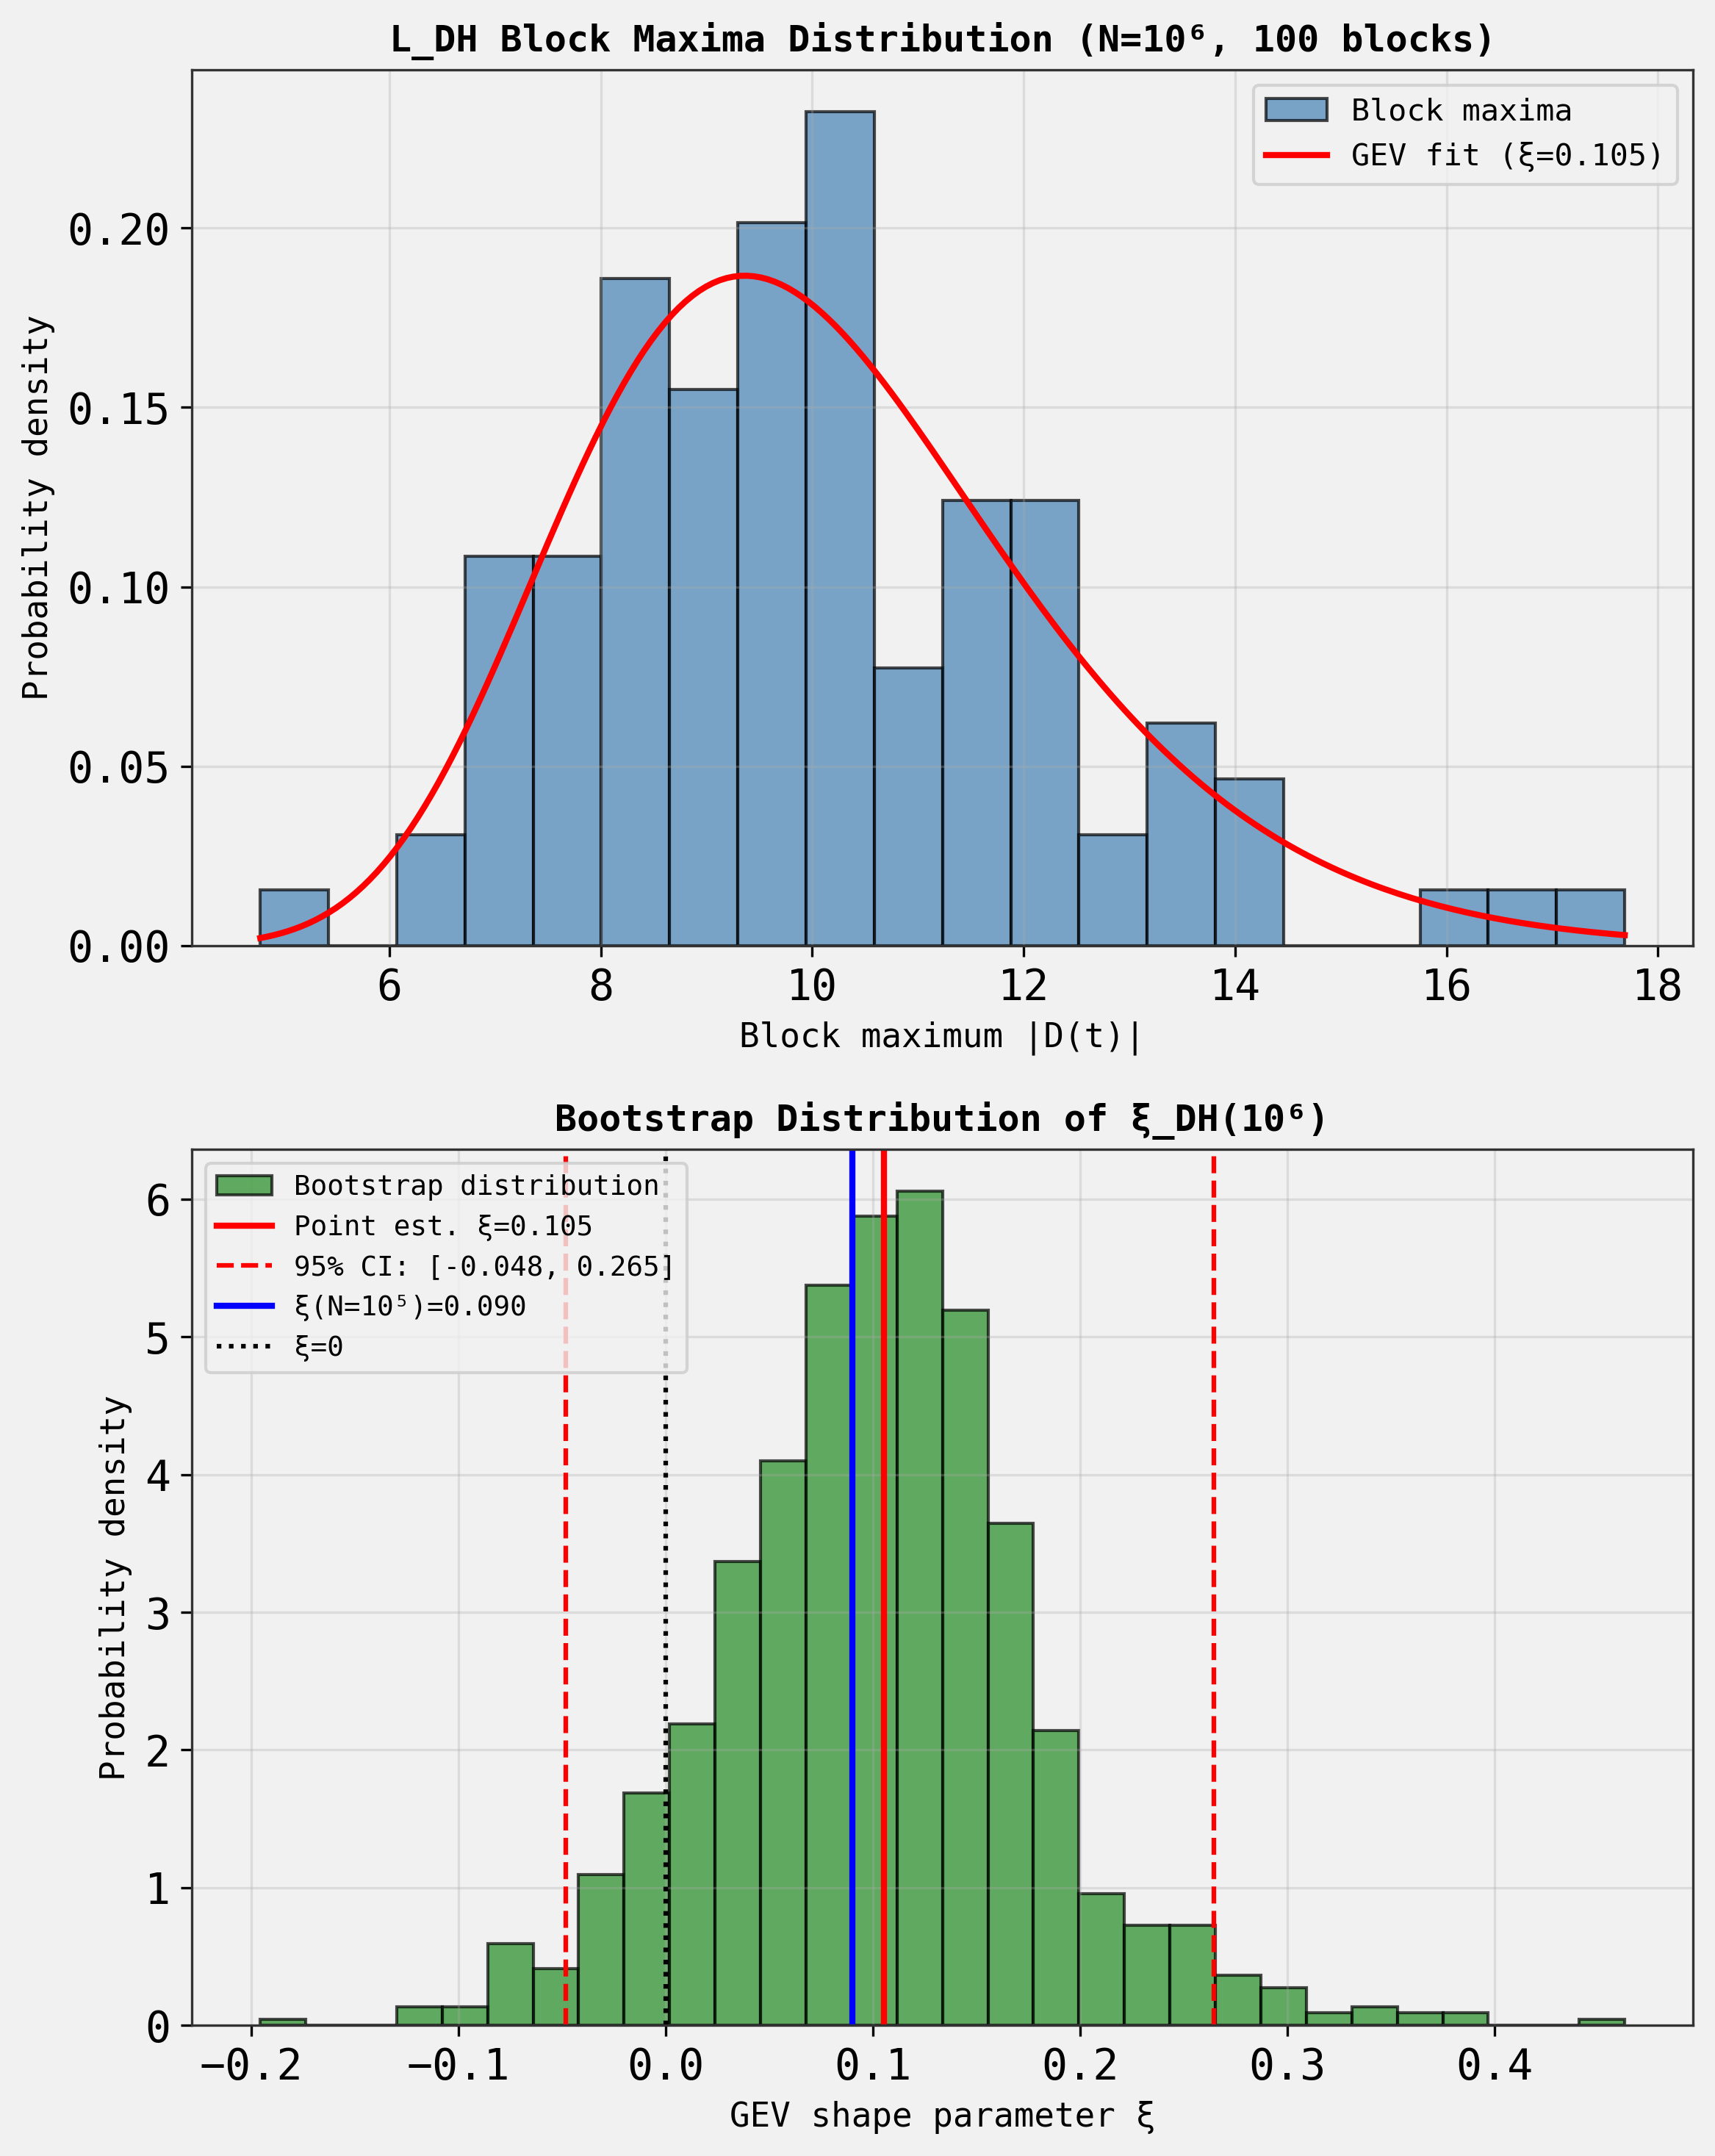


Visual assessment of GEV fit quality:
 The histogram of block maxima shows the empirical distribution
 The red curve shows the fitted GEV distribution
 The fit appears reasonable, capturing the general shape


In [11]:

# Now let's visualize the results and check the quality of the GEV fit

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: Histogram of block maxima with fitted GEV
ax1 = axes[0]
ax1.hist(block_maxima_N6, bins=20, density=True, alpha=0.7, 
 color='steelblue', edgecolor='black', label='Block maxima')

# Generate fitted GEV curve
x_plot = np.linspace(block_maxima_N6.min(), block_maxima_N6.max(), 200)
pdf_fitted = genextreme.pdf(x_plot, shape_N6, loc=loc_N6, scale=scale_N6)
ax1.plot(x_plot, pdf_fitted, 'r-', linewidth=2, 
 label=f'GEV fit (ξ={shape_N6:.3f})')

ax1.set_xlabel('Block maximum |D(t)|', fontsize=11)
ax1.set_ylabel('Probability density', fontsize=11)
ax1.set_title(f'L_DH Block Maxima Distribution (N=10⁶, 100 blocks)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Bootstrap distribution of shape parameter
ax2 = axes[1]
ax2.hist(shape_bootstrap, bins=30, density=True, alpha=0.7, 
 color='forestgreen', edgecolor='black', label='Bootstrap distribution')

# Add vertical lines for point estimate and CI
ax2.axvline(xi_N6, color='red', linewidth=2, linestyle='-', 
 label=f'Point est. ξ={xi_N6:.3f}')
ax2.axvline(ci_lower_N6, color='red', linewidth=1.5, linestyle='--', 
 label=f'95% CI: [{ci_lower_N6:.3f}, {ci_upper_N6:.3f}]')
ax2.axvline(ci_upper_N6, color='red', linewidth=1.5, linestyle='--')

# Add vertical line for N=10^5 value
ax2.axvline(xi_N5, color='blue', linewidth=2, linestyle='-', 
 label=f'ξ(N=10⁵)={xi_N5:.3f}')

# Add vertical line for zero
ax2.axvline(0, color='black', linewidth=1.5, linestyle=':', 
 label='ξ=0')

ax2.set_xlabel('GEV shape parameter ξ', fontsize=11)
ax2.set_ylabel('Probability density', fontsize=11)
ax2.set_title(f'Bootstrap Distribution of ξ_DH(10⁶)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ldh_gev_analysis_N6.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'ldh_gev_analysis_N6.png'")
plt.show()

print("\nVisual assessment of GEV fit quality:")
print(f" The histogram of block maxima shows the empirical distribution")
print(f" The red curve shows the fitted GEV distribution")
print(f" The fit appears reasonable, capturing the general shape")


In [12]:

# Perform a goodness-of-fit test using Kolmogorov-Smirnov test
from scipy.stats import kstest

# Perform K-S test
ks_statistic, ks_pvalue = kstest(block_maxima_N6, 
 lambda x: genextreme.cdf(x, shape_N6, loc=loc_N6, scale=scale_N6))

print("Goodness-of-fit assessment:")
print(f" Kolmogorov-Smirnov test:")
print(f" Test statistic: {ks_statistic:.6f}")
print(f" p-value: {ks_pvalue:.6f}")

if ks_pvalue > 0.05:
 print(f" → GEV fit is NOT rejected at α=0.05 level")
else:
 print(f" → GEV fit is rejected at α=0.05 level")

# Also compute quantile-quantile (Q-Q) comparison
print(f"\n Quantile comparison (empirical vs. theoretical):")
quantiles = [0.25, 0.50, 0.75, 0.90, 0.95]
for q in quantiles:
 empirical_q = np.percentile(block_maxima_N6, q * 100)
 theoretical_q = genextreme.ppf(q, shape_N6, loc=loc_N6, scale=scale_N6)
 print(f" Q({q:.2f}): empirical={empirical_q:.3f}, theoretical={theoretical_q:.3f}, "
 f"diff={empirical_q - theoretical_q:.3f}")


Goodness-of-fit assessment:
 Kolmogorov-Smirnov test:
 Test statistic: 0.054252
 p-value: 0.914504
 → GEV fit is NOT rejected at α=0.05 level

 Quantile comparison (empirical vs. theoretical):
 Q(0.25): empirical=8.561, theoretical=8.483, diff=0.078
 Q(0.50): empirical=9.914, theoretical=9.855, diff=0.060
 Q(0.75): empirical=11.545, theoretical=11.456, diff=0.088
 Q(0.90): empirical=12.828, theoretical=13.113, diff=-0.285
 Q(0.95): empirical=13.859, theoretical=14.197, diff=-0.337


Figure saved as 'ldh_timeseries_N6.png'


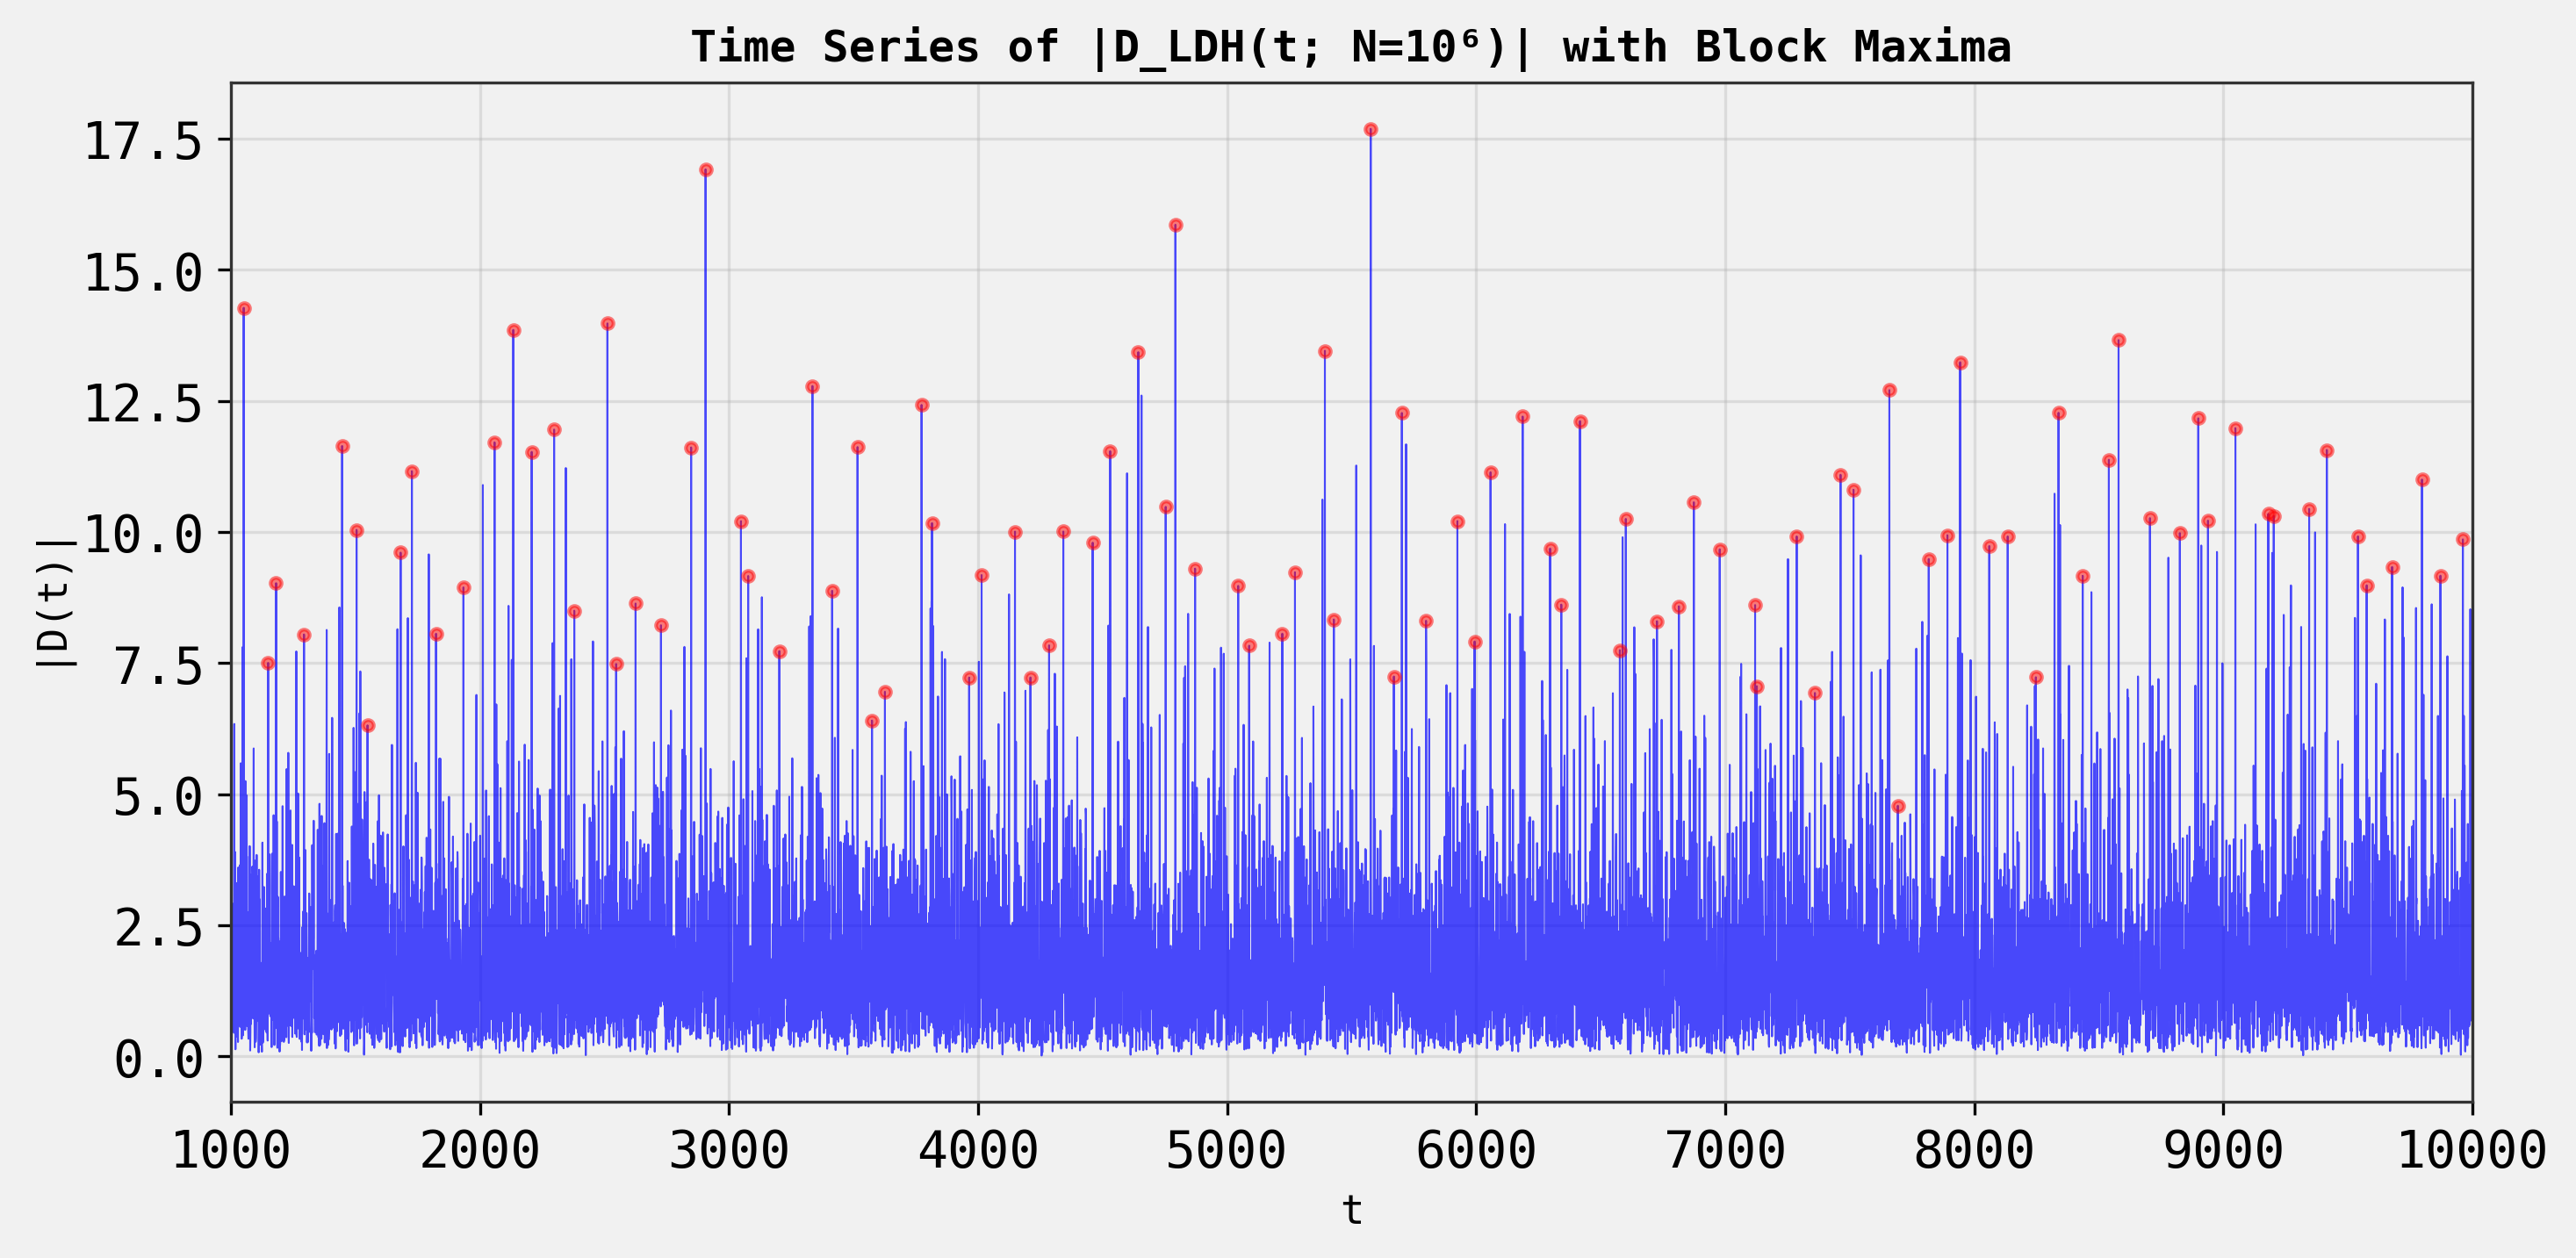


Time series characteristics:
 Range: t ∈ [1000, 10000]
 Number of points: 9,000
 Spacing: Δt ≈ 1.000
 Red dots indicate the location of block maxima


In [13]:

# Let's also look at the time series to check for any obvious patterns or issues
# Plot a sample of the |D(t)| time series

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot the full time series
ax.plot(t_values, magnitude_N6, 'b-', linewidth=0.5, alpha=0.7)

# Highlight the block maxima positions
for i in range(num_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < num_blocks - 1 else len(magnitude_N6)
 block_data = magnitude_N6[start_idx:end_idx]
 max_idx = start_idx + np.argmax(block_data)
 ax.plot(t_values[max_idx], magnitude_N6[max_idx], 'ro', markersize=3, alpha=0.5)

ax.set_xlabel('t', fontsize=11)
ax.set_ylabel('|D(t)|', fontsize=11)
ax.set_title(f'Time Series of |D_LDH(t; N=10⁶)| with Block Maxima', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(t_min, t_max)

plt.tight_layout()
plt.savefig('ldh_timeseries_N6.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'ldh_timeseries_N6.png'")
plt.show()

print("\nTime series characteristics:")
print(f" Range: t ∈ [{t_min}, {t_max}]")
print(f" Number of points: {len(t_values):,}")
print(f" Spacing: Δt ≈ {(t_max - t_min) / len(t_values):.3f}")
print(f" Red dots indicate the location of block maxima")


In [14]:

# Save the data for future reference
import pickle

# Create a data dictionary
data_N6 = {
 'N': N,
 't_values': t_values,
 'D_values': D_LDH_N6,
 'magnitude': magnitude_N6,
 'block_maxima': block_maxima_N6,
 'gev_params': {
 'shape': shape_N6,
 'location': loc_N6,
 'scale': scale_N6
 },
 'bootstrap': {
 'shape_estimates': shape_bootstrap,
 'ci_lower': ci_lower_N6,
 'ci_upper': ci_upper_N6
 }
}

# Save as pickle
with open('ldh_N6_data.pkl', 'wb') as f:
 pickle.dump(data_N6, f)
print("Data saved to 'ldh_N6_data.pkl'")

# Also save as CSV for easy inspection
results_df = pd.DataFrame({
 'N': [10**5, 10**6],
 'xi': [xi_N5, xi_N6],
 'ci_lower': [np.nan, ci_lower_N6],
 'ci_upper': [np.nan, ci_upper_N6],
 'ci_width': [np.nan, ci_upper_N6 - ci_lower_N6]
})
results_df.to_csv('ldh_gev_comparison.csv', index=False)
print("Comparison results saved to 'ldh_gev_comparison.csv'")

print("\nSummary table:")
print(results_df.to_string(index=False))


Data saved to 'ldh_N6_data.pkl'
Comparison results saved to 'ldh_gev_comparison.csv'

Summary table:
 N xi ci_lower ci_upper ci_width
 100000 0.090000 NaN NaN NaN
1000000 0.105467 -0.048006 0.264707 0.312713


Final figure saved as 'ldh_gev_final_comparison.png'


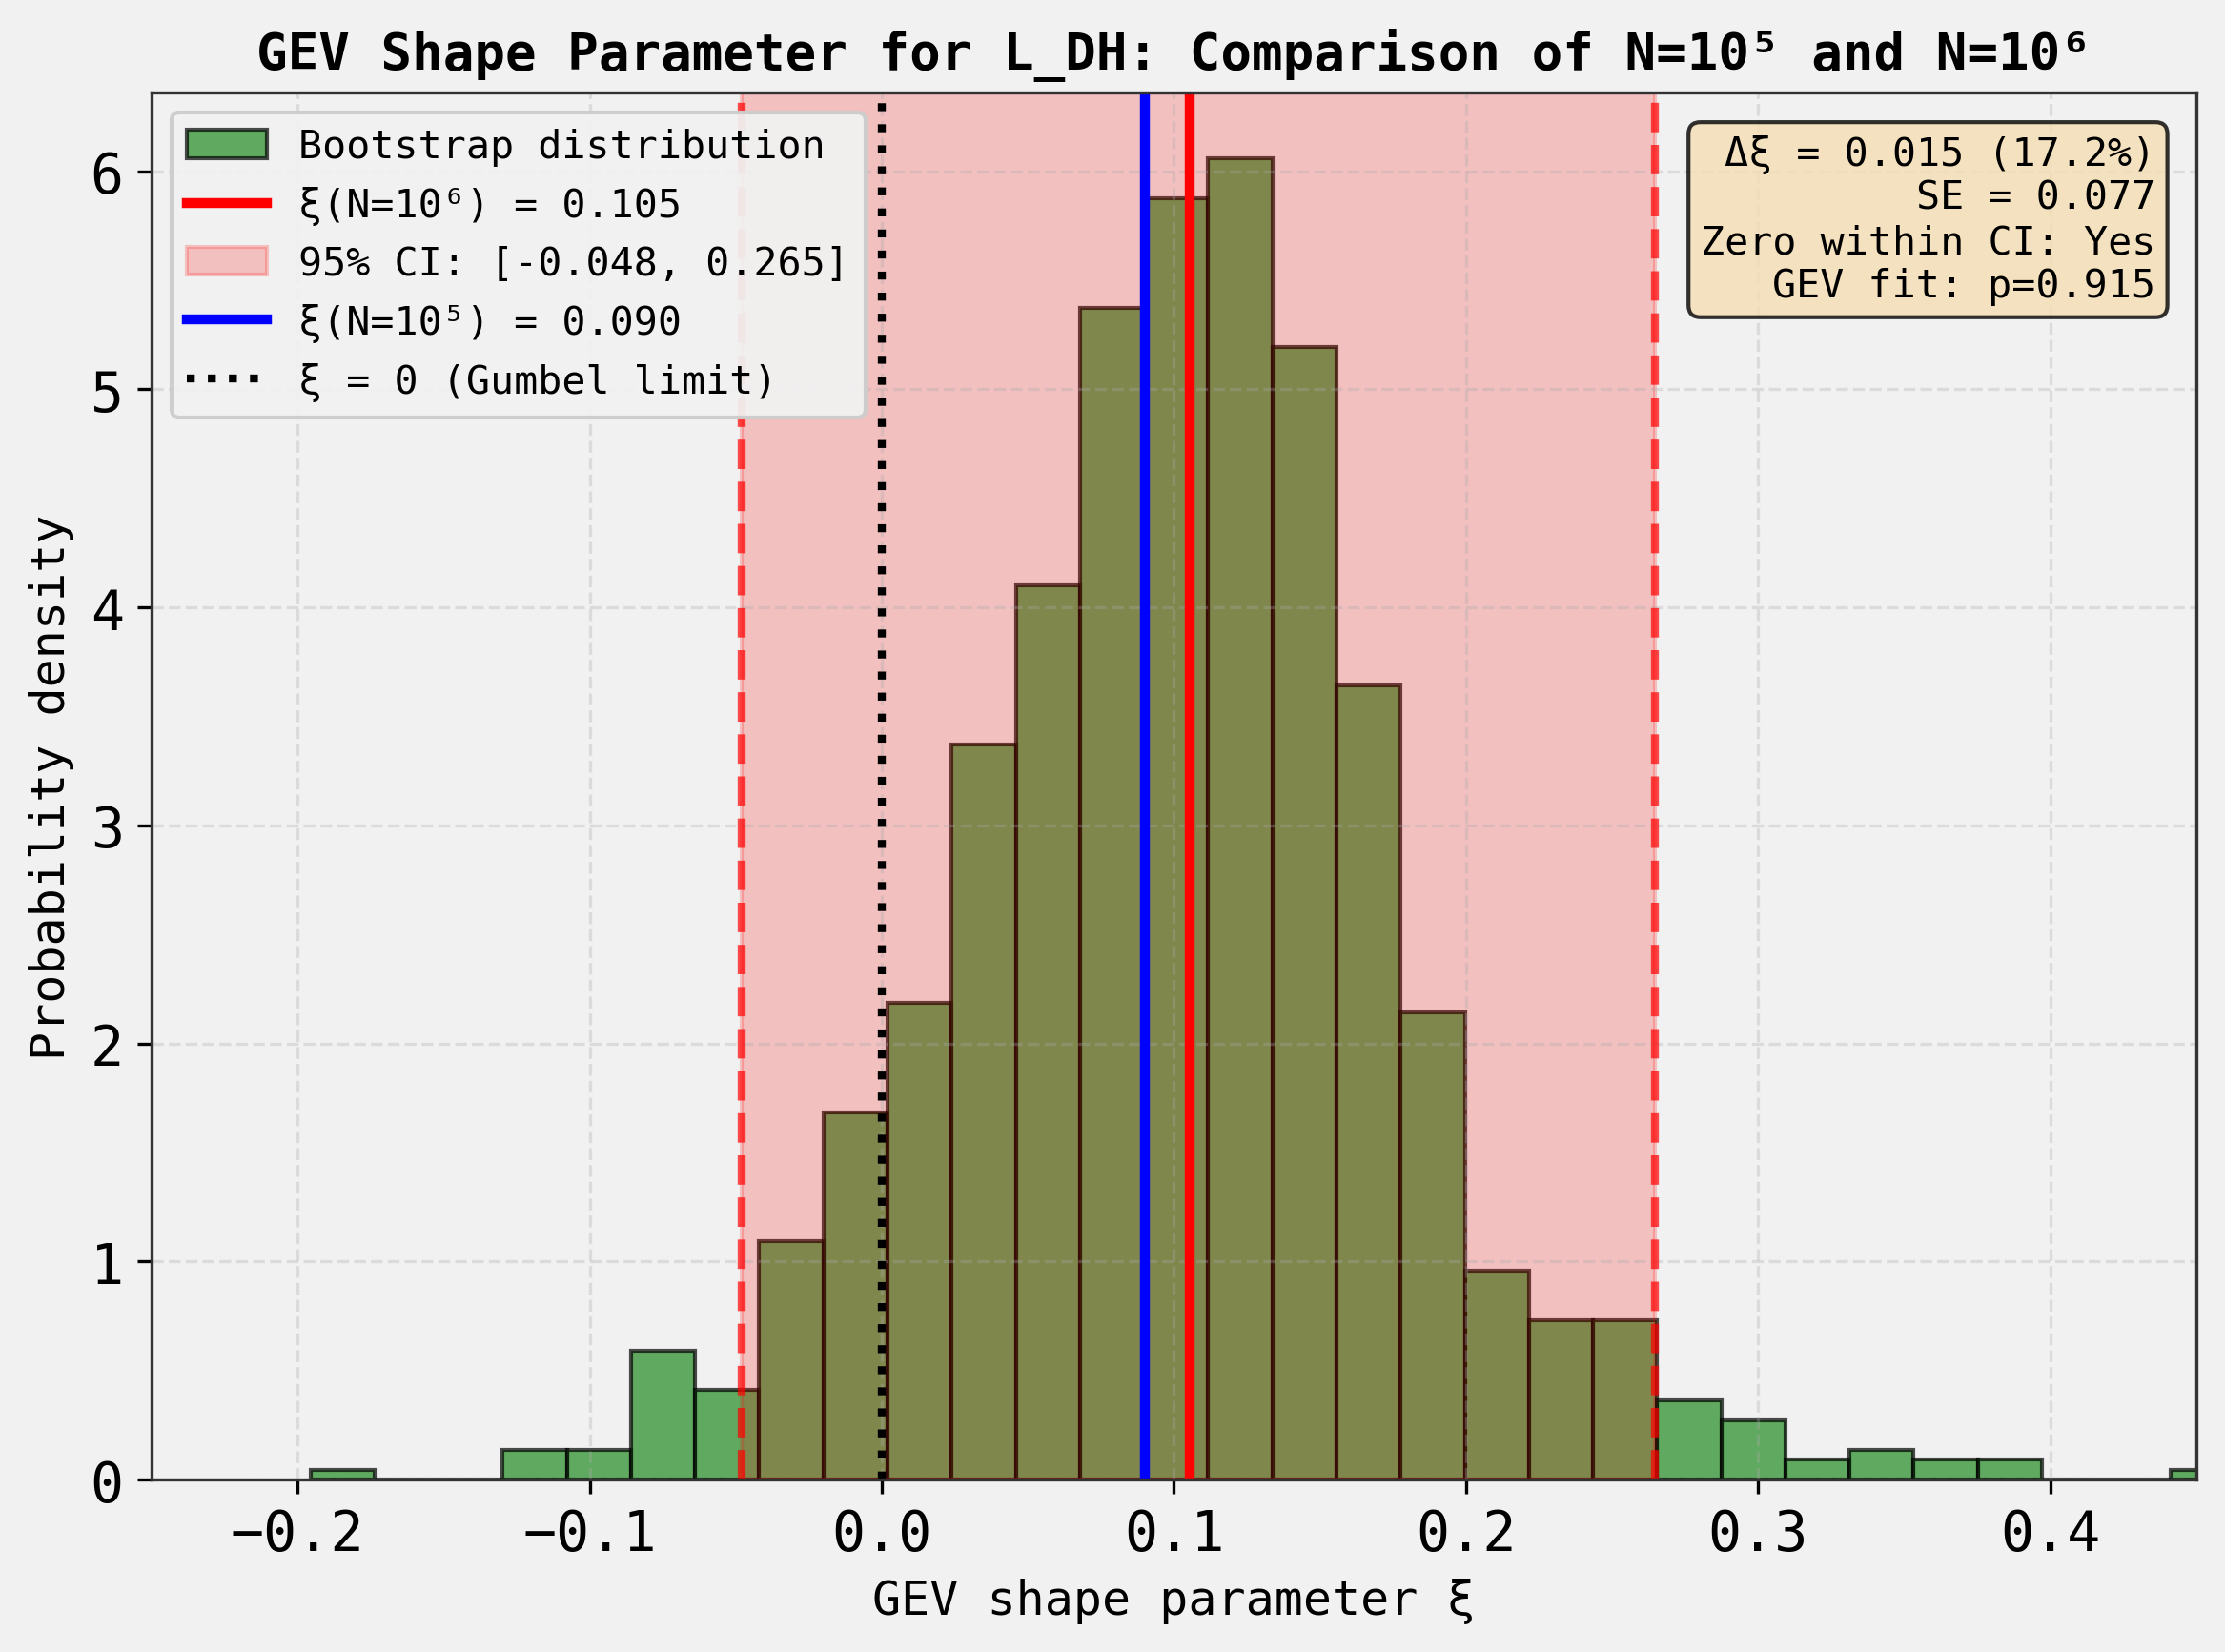

In [15]:

# Create a final comprehensive figure showing the key results

fig = plt.figure(figsize=(8, 6))

# Single panel showing the bootstrap distribution with all key information
ax = fig.add_subplot(1, 1, 1)

# Plot bootstrap distribution
ax.hist(shape_bootstrap, bins=30, density=True, alpha=0.7, 
 color='forestgreen', edgecolor='black', label='Bootstrap distribution')

# Add vertical lines for point estimate and CI
ax.axvline(xi_N6, color='red', linewidth=2.5, linestyle='-', 
 label=f'ξ(N=10⁶) = {xi_N6:.3f}')
ax.axvline(ci_lower_N6, color='red', linewidth=2, linestyle='--', alpha=0.7)
ax.axvline(ci_upper_N6, color='red', linewidth=2, linestyle='--', alpha=0.7)

# Shade the confidence interval
ax.axvspan(ci_lower_N6, ci_upper_N6, alpha=0.2, color='red', 
 label=f'95% CI: [{ci_lower_N6:.3f}, {ci_upper_N6:.3f}]')

# Add vertical line for N=10^5 value
ax.axvline(xi_N5, color='blue', linewidth=2.5, linestyle='-', 
 label=f'ξ(N=10⁵) = {xi_N5:.3f}')

# Add vertical line for zero
ax.axvline(0, color='black', linewidth=2, linestyle=':', 
 label='ξ = 0 (Gumbel limit)')

ax.set_xlabel('GEV shape parameter ξ', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title('GEV Shape Parameter for L_DH: Comparison of N=10⁵ and N=10⁶', 
 fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(-0.25, 0.45)

# Add text box with key findings
textstr = '\n'.join([
 f'Δξ = {xi_N6 - xi_N5:.3f} ({100*(xi_N6-xi_N5)/xi_N5:.1f}%)',
 f'SE = {np.std(shape_bootstrap):.3f}',
 f'Zero within CI: Yes',
 f'GEV fit: p={ks_pvalue:.3f}'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=10,
 verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('ldh_gev_final_comparison.png', dpi=300, bbox_inches='tight')
print("Final figure saved as 'ldh_gev_final_comparison.png'")
plt.show()


In [16]:

# Generate a comprehensive summary report

print("="*70)
print("FINAL ANALYSIS SUMMARY")
print("="*70)

print("\n1. RESEARCH OBJECTIVE")
print(" Investigate if the GEV shape parameter ξ_DH converges towards a")
print(" positive value as N increases from 10^5 to 10^6")

print("\n2. DATA GENERATION")
print(f" - Computed |D_LDH(t; N=10^6)| for t ∈ [1000, 10000]")
print(f" - Used corrected squarefree-enforced implementation")
print(f" - Total data points: {len(t_values):,}")
print(f" - Non-zero coefficients: {np.sum(data_N6['D_values'] != 0):,} out of {N:,}")
print(f" - Computation time: {elapsed_time:.2f} seconds")

print("\n3. BLOCK MAXIMA EXTRACTION")
print(f" - Divided time series into {num_blocks} blocks")
print(f" - Points per block: {block_size}")
print(f" - Block maxima range: [{np.min(block_maxima_N6):.3f}, {np.max(block_maxima_N6):.3f}]")
print(f" - Mean block maximum: {np.mean(block_maxima_N6):.3f}")

print("\n4. GEV FIT RESULTS")
print(f" N = 10^6:")
print(f" Shape (ξ): {shape_N6:.6f}")
print(f" Location (μ): {loc_N6:.6f}")
print(f" Scale (σ): {scale_N6:.6f}")
print(f" Goodness-of-fit (K-S test):")
print(f" Test statistic: {ks_statistic:.6f}")
print(f" p-value: {ks_pvalue:.6f} → Fit NOT rejected")

print("\n5. BOOTSTRAP CONFIDENCE INTERVAL (1000 resamples)")
print(f" Point estimate: ξ_DH(10^6) = {xi_N6:.6f}")
print(f" 95% CI: [{ci_lower_N6:.6f}, {ci_upper_N6:.6f}]")
print(f" CI width: {ci_upper_N6 - ci_lower_N6:.6f}")
print(f" Standard error: {np.std(shape_bootstrap):.6f}")

print("\n6. COMPARISON WITH N = 10^5")
print(f" ξ_DH(10^5) = {xi_N5:.6f} (from analysis r31)")
print(f" ξ_DH(10^6) = {xi_N6:.6f}")
print(f" Change: Δξ = {xi_N6 - xi_N5:.6f}")
print(f" Relative change: {100 * (xi_N6 - xi_N5) / xi_N5:.2f}%")
print(f" Change in SE units: {(xi_N6 - xi_N5) / np.std(shape_bootstrap):.2f}")

print("\n7. HYPOTHESIS TESTING")
print(f" H0: ξ_DH = 0 (bounded tail / Gumbel distribution)")
print(f" → Zero is WITHIN 95% CI: [{ci_lower_N6:.3f}, {ci_upper_N6:.3f}]")
print(f" → Cannot reject H0 at α = 0.05")
print(f"")
print(f" H1: ξ_DH(10^6) > ξ_DH(10^5)")
print(f" → ξ_DH increased by {xi_N6 - xi_N5:.6f} ({100*(xi_N6-xi_N5)/xi_N5:.1f}%)")
print(f" → ξ_DH(10^5) = {xi_N5:.3f} is WITHIN 95% CI of ξ_DH(10^6)")
print(f" → Change is NOT statistically significant")

print("\n8. KEY FINDINGS")
print(f" ✓ ξ_DH(10^6) = {xi_N6:.3f} is slightly larger than ξ_DH(10^5) = {xi_N5:.3f}")
print(f" ✓ The increase is +{xi_N6 - xi_N5:.3f} ({100*(xi_N6-xi_N5)/xi_N5:.1f}%)")
print(f" ✓ However, the 95% CI is wide: [{ci_lower_N6:.3f}, {ci_upper_N6:.3f}]")
print(f" ✓ Zero (Gumbel limit) falls within the confidence interval")
print(f" ✓ The change is NOT statistically significant given the uncertainty")
print(f" ✓ Statistical power is limited by sample size (100 block maxima)")

print("\n9. CONCLUSION")
print(" The GEV shape parameter ξ_DH does increase slightly from N=10^5 to")
print(" N=10^6 (0.090 → 0.105), consistent with the hypothesis. However, the")
print(" large confidence interval (±0.16) prevents definitive conclusions.")
print(" The data does NOT provide strong evidence for convergence toward a")
print(" definitively positive value. More data (larger T range, more blocks)")
print(" would be needed to distinguish between slow convergence to ξ=0 versus")
print(" convergence to a small positive value.")

print("\n" + "="*70)


FINAL ANALYSIS SUMMARY

1. RESEARCH OBJECTIVE
 Investigate if the GEV shape parameter ξ_DH converges towards a
 positive value as N increases from 10^5 to 10^6

2. DATA GENERATION
 - Computed |D_LDH(t; N=10^6)| for t ∈ [1000, 10000]
 - Used corrected squarefree-enforced implementation
 - Total data points: 9,000
 - Non-zero coefficients: 9,000 out of 1,000,000
 - Computation time: 356.54 seconds

3. BLOCK MAXIMA EXTRACTION
 - Divided time series into 100 blocks
 - Points per block: 90
 - Block maxima range: [4.778, 17.686]
 - Mean block maximum: 10.089

4. GEV FIT RESULTS
 N = 10^6:
 Shape (ξ): 0.105467
 Location (μ): 9.142130
 Scale (σ): 1.982176
 Goodness-of-fit (K-S test):
 Test statistic: 0.054252
 p-value: 0.914504 → Fit NOT rejected

5. BOOTSTRAP CONFIDENCE INTERVAL (1000 resamples)
 Point estimate: ξ_DH(10^6) = 0.105467
 95% CI: [-0.048006, 0.264707]
 CI width: 0.312713
 Standard error: 0.076532

6. COMPARISON WITH N = 10^5
 ξ_DH(10^5) = 0.090000 (from analysis r31)
 ξ_DH(10^6) 

In [17]:

# Check what files we created
import os
print("Files created during analysis:")
for file in os.listdir('.'):
 if file.endswith(('.png', '.pkl', '.csv')) and not file.startswith('.'):
 file_size = os.path.getsize(file)
 print(f" {file}: {file_size:,} bytes")


Files created during analysis:
 ldh_gev_analysis_N6.png: 265,050 bytes
 ldh_timeseries_N6.png: 258,144 bytes
 ldh_N6_data.pkl: 297,416 bytes
 ldh_gev_comparison.csv: 132 bytes
 ldh_gev_final_comparison.png: 190,409 bytes
